In [ ]:
%pip install networkx
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


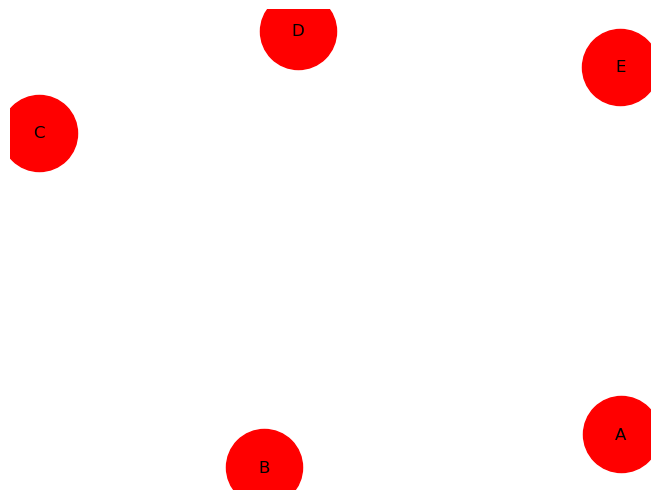

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
G = nx.Graph()
G.add_node("A")
G.add_node("B")
G.add_node("C")
G.add_node("D")
G.add_node("E")

seed = 5

nx.draw(G, with_labels=True, node_color="red", node_size=3000)
plt.show()

In [4]:
import networkx as nx

# Create a directed graph (flow problems use directed edges)
G = nx.DiGraph()

# Add edges with capacities
G.add_edge("S", "A", capacity=10)
G.add_edge("S", "C", capacity=10)
G.add_edge("A", "B", capacity=4)
G.add_edge("A", "C", capacity=2)
G.add_edge("C", "D", capacity=9)
G.add_edge("D", "B", capacity=6)
G.add_edge("B", "T", capacity=10)
G.add_edge("D", "T", capacity=10)

source = "S"
sink = "T"

# Compute maximum flow
flow_value, flow_dict = nx.maximum_flow(G, source, sink)

print("Max flow value:", flow_value)
print("Flow on each edge:")
for u in flow_dict:
    for v, f in flow_dict[u].items():
        if f > 0:
            print(f"{u} -> {v}: {f}")

Max flow value: 13
Flow on each edge:
S -> A: 6
S -> C: 7
A -> B: 4
A -> C: 2
C -> D: 9
B -> T: 4
D -> T: 9


In [10]:
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

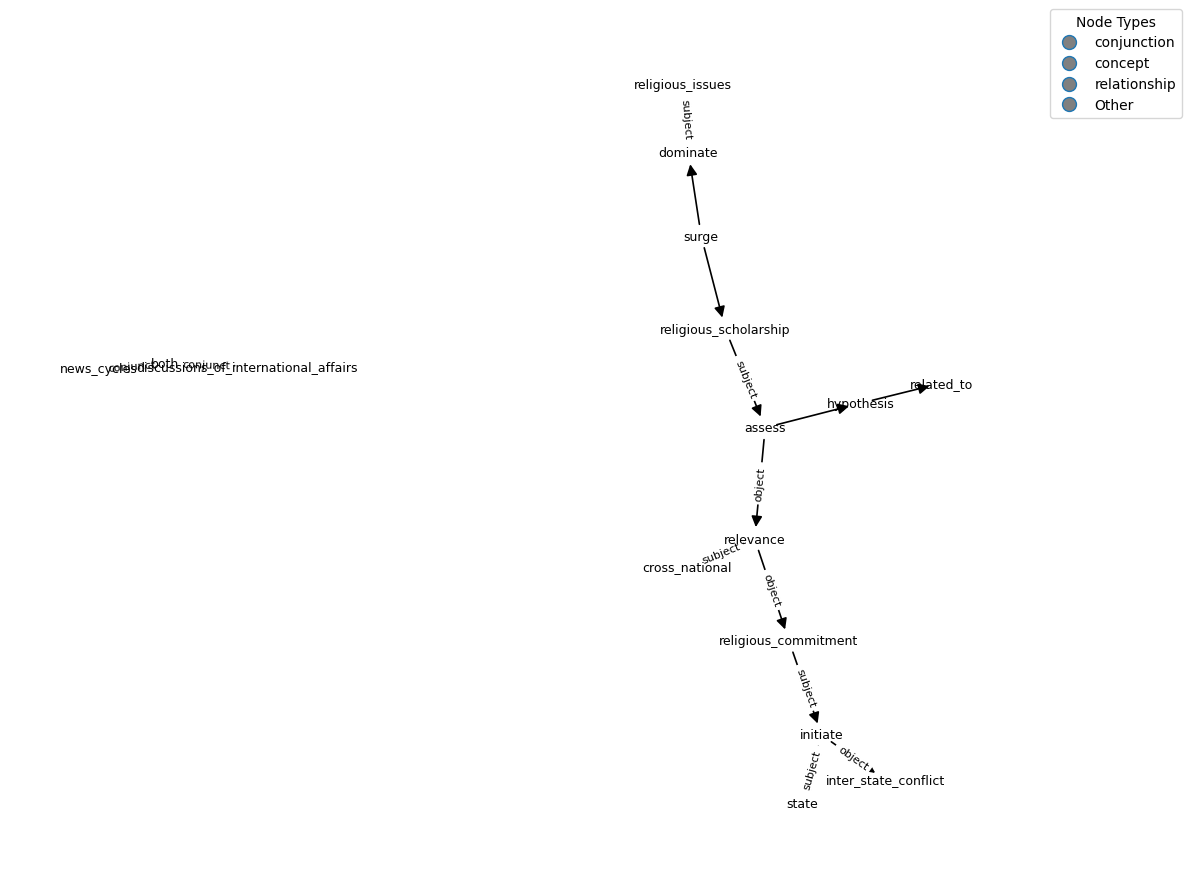

Loaded graph: Graph
Nodes: 16 | Edges: 14
Saved image to: C:\WorldView\worldview\graphML.png


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# GraphML file path
GRAPHML_PATH = Path(r"C:\WorldView\worldview\test1_v2.graphml")   # Windows
# GRAPHML_PATH = Path("/Users/nick/Documents/my_graph.graphml")    # Mac

NODE_LABEL_ATTR = None         # e.g. "label" or "name" or leave None to use node id
EDGE_LABEL_ATTR = "Edge_Type"  # e.g. "weight" or "capacity" or leave None for no edge labels
NODE_TYPE_ATTR = "Node_Type"   # change to "Type" if file says "Type" ##GraphML node attribute name

OUT_IMAGE = Path("graphML.png")

def main():
    if not GRAPHML_PATH.exists():
        raise FileNotFoundError(f"GraphML file not found: {GRAPHML_PATH}")

    G = nx.read_graphml(GRAPHML_PATH)
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 9))

    # --- Node Color Type ---
    Node_Type = {
        "Person": "red",
        "Organization": "green",
        "Location": "blue",
        "Event": "orange",
        "Concept": "purple",
        "Conjunction": "yellow",
        "Other": "gray",  # default for unknown/missing
    }

    # --- Build node color list---
    node_colors = []
    for n in G.nodes():
        t = G.nodes[n].get(NODE_TYPE_ATTR, "Other")
        t = str(t).strip()
        node_colors.append(Node_Type.get(t, Node_Type["Other"]))

    # --- Drawing the Nodes ---
    nx.draw_networkx_nodes(
        G, pos,
        node_size=600,
        node_color=node_colors
    )

    # --- Draw edges with arrowheads ---
    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=16,
        width=1.2
        # connectionstyle="arc3,rad=0.08"  # uncomment for curved edges
    )

    # --- Node labels ---
    if NODE_LABEL_ATTR:
        node_labels = {n: str(G.nodes[n].get(NODE_LABEL_ATTR, n)) for n in G.nodes()}
    else:
        node_labels = {n: str(n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9)

    # --- Edge labels ---
    if EDGE_LABEL_ATTR:
        edge_labels = {}
        if G.is_multigraph():
            for u, v, k, data in G.edges(keys=True, data=True):
                if EDGE_LABEL_ATTR in data:
                    edge_labels[(u, v)] = str(data[EDGE_LABEL_ATTR])
        else:
            for u, v, data in G.edges(data=True):
                if EDGE_LABEL_ATTR in data:
                    edge_labels[(u, v)] = str(data[EDGE_LABEL_ATTR])

        if edge_labels:
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # --- Legend for node types (only show types that exist in the graph) ---
    present_types = []
    for n in G.nodes():
        t = str(G.nodes[n].get(NODE_TYPE_ATTR, "Other")).strip()
        if t not in present_types:
            present_types.append(t)

    legend_handles = []
    for t in present_types:
        c = Node_Type.get(t, Node_Type["Other"])
        legend_handles.append(Line2D([0], [0], marker='o', linestyle='',
                                    markerfacecolor=c, markersize=10, label=t))

    if legend_handles:
        plt.legend(handles=legend_handles, title="Node Types",
                   loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_IMAGE, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Loaded graph: {G.__class__.__name__}")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    print(f"Saved image to: {OUT_IMAGE.resolve()}")

if __name__ == "__main__":
    main()

In [40]:
import networkx as nx
from pathlib import Path

GRAPHML_PATH = Path(r"C:\WorldView\worldview\test1_v2.graphml")
NODE_TYPE_ATTR = "Node_Type"
Node_Type = {
    "Person": "red",
    "Organization": "green",
    "Location": "blue",
    "Event": "orange",
    "Concept": "purple",
    "Conjunction": "yellow",
    "Other": "gray",
}

G = nx.read_graphml(GRAPHML_PATH)
node_colors = [
    Node_Type.get(str(G.nodes[n].get(NODE_TYPE_ATTR, "Other")).strip(), Node_Type["Other"])
    for n in G.nodes()
]
print(node_colors)  # list of colors in node iteration order
print({n: Node_Type.get(str(G.nodes[n].get(NODE_TYPE_ATTR, "Other")).strip(), Node_Type["Other"]) for n in G.nodes()})  # mapping node -> color

['gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'gray']
{'religious_issues': 'gray', 'discussions_of_international_affairs': 'gray', 'news_cycles': 'gray', 'surge': 'gray', 'religious_scholarship': 'gray', 'assess': 'gray', 'relevance': 'gray', 'cross_national': 'gray', 'religious_commitment': 'gray', 'hypothesis': 'gray', 'related_to': 'gray', 'initiate': 'gray', 'dominate': 'gray', 'both': 'gray', 'state': 'gray', 'inter_state_conflict': 'gray'}
